# 06 — Metadata Scarcity and the Two-Stage Warfield Detector

Five detectors on the level>=1 packages under clean, adversarial, and absent metadata, plus a
coverage sweep from 100% to 0%. The two-stage detector trains a seeder on level-0
manufacturers only and propagates those scores at the alpha inherited from notebook 04, so no
package is ever scored from its own manifest.


## 1. Imports & config

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json, os, time
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.csgraph import dijkstra
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

from common import (ECO_TITLES, MIN_VIEW_POS, N_JOBS, SEED, build_graph_structures,
                    make_views, read_csv_literal)

ECO       = os.environ.get("ECO", "npm")
ECO_TITLE = ECO_TITLES[ECO]
MIN_STAGE2_POS = 5

ROOT    = Path("..")
PREP    = ROOT / "data" / "output" / ECO / "01_data_prep"
NOISY   = ROOT / "data" / "output" / ECO / "04_noisy-or-sweep"
OUT_DIR = ROOT / "data" / "output" / ECO / "06_metadata_scarcity"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONDITIONS = ["Clean", "Benign-imputation", "Greedy evasion", "No metadata (zeroed)"]
COVERAGES  = [1.0, 0.75, 0.5, 0.25, 0.1, 0.0]
DET_COLORS = {"Metadata": "#e87ba4", "Graph-11": "#5a5952", "Metadata+Graph": "#eda100",
              "Two-stage Warfield": "#2a78d6", "Two-stage + metadata": "#008300"}

t_nb = time.time()
print(f"{ECO_TITLE} | out: {OUT_DIR.resolve()}")


npm | out: C:\Users\amehs\Documents\ThesisAppendixVersion\data\output\npm\06_metadata_scarcity


## 2. Load corpus, canonical structural features, and the inherited α

In [2]:
schema = json.loads((PREP / "schema.json").read_text(encoding="utf-8"))
df = read_csv_literal(PREP / "model_ready_dataset.csv")
gf = read_csv_literal(PREP / "graph_features.csv")
edges = read_csv_literal(PREP / "edges.csv")
alpha_cfg = json.loads((NOISY / "best_alpha.json").read_text(encoding="utf-8"))["best_per_view"]

GRAPH_FEATURES = schema["graph_features"]
META_FEATURES  = schema["meta_features"]
assert len(GRAPH_FEATURES) == 11 and list(gf.columns)[3:] == GRAPH_FEATURES
assert (df["package"] == gf["package"]).all()

N = len(df)
label_arr = df["label"].astype(int).to_numpy()
VIEWS = make_views(label_arr, restrict_to=alpha_cfg)

X_meta  = df[META_FEATURES].apply(pd.to_numeric, errors="coerce").values.astype(np.float32)
X_graph = gf[GRAPH_FEATURES].values.astype(np.float32)
N_META = X_meta.shape[1]

pos_of = {p: i for i, p in enumerate(df["package"])}
src = edges["source"].map(pos_of).to_numpy(dtype=np.int64)
tgt = edges["target"].map(pos_of).to_numpy(dtype=np.int64)
conn_pkg = gf["connected"].to_numpy(dtype=bool)

ALPHA_FOR = {}
for vname in VIEWS:
    c = alpha_cfg[vname]
    if c["propagation_recommended"]:
        ALPHA_FOR[vname] = (float(c["alpha"]), str(c["variant"]), "inherited from notebook 04")
    else:
        ALPHA_FOR[vname] = (float(c["alpha_best_prauc"]), str(c["variant_best_prauc"]),
                            "PR-AUC argmax; notebook 04 found this DEGRADES the base score")
    print(f"  [{vname:12s}] alpha={ALPHA_FOR[vname][0]:g} {ALPHA_FOR[vname][1]}  "
          f"({ALPHA_FOR[vname][2]})")

print(f"\n{ECO_TITLE}: {N:,} packages | metadata {N_META} | graph {len(GRAPH_FEATURES)} | "
      f"NaN in metadata {int(np.isnan(X_meta).sum()):,}")

  [compromised ] alpha=0.1 Weighted (log dp)  (inherited from notebook 04)
  [risky       ] alpha=0.1 Weighted (dp)  (inherited from notebook 04)

npm: 101,350 packages | metadata 56 | graph 11 | NaN in metadata 114,055


## 3. Warfield levels and the Stage-1 / Stage-2 partition

In [3]:
gs = build_graph_structures(src, tgt, N)
n_scc, scc, lev, topo = gs["n_scc"], gs["scc"], gs["lev"], gs["topo"]
level_pkg = lev[scc]; maxlev = int(lev.max())
dp_scc = np.zeros(n_scc)
np.maximum.at(dp_scc, scc, np.expm1(gf["log1p_driving_power"].to_numpy()))

E_dep = gs["dag_edges"][:, 0].astype(np.int64)
E_dpy = gs["dag_edges"][:, 1].astype(np.int64)
if len(E_dep):
    _o = np.argsort(lev[E_dep], kind="stable")
    E_dep, E_dpy = E_dep[_o], E_dpy[_o]
    lev_start = np.searchsorted(lev[E_dep], np.arange(maxlev + 2))
else:
    lev_start = np.zeros(maxlev + 2, np.int64)
nodes_by_level = [np.flatnonzero(lev == L) for L in range(maxlev + 1)]
W_SCC = {"Unweighted": None,
         "Weighted (dp)": dp_scc / max(dp_scc.max(), 1.0),
         "Weighted (log dp)": np.log1p(np.maximum(dp_scc, 0)) / max(np.log1p(dp_scc.max()), 1e-12)}


def noisy_or_propagate(base_scc, alpha, w_scc=None):
    r = np.asarray(base_scc, dtype=np.float64).copy()
    logacc = np.zeros(n_scc)
    for L in range(1, maxlev + 1):
        a, b = int(lev_start[L]), int(lev_start[L + 1])
        if b > a:
            ae = alpha if w_scc is None else alpha * w_scc[E_dpy[a:b]]
            np.add.at(logacc, E_dep[a:b],
                      np.log(np.clip(1.0 - ae * r[E_dpy[a:b]], 1e-300, 1.0)))
        nds = nodes_by_level[L]
        if len(nds):
            r[nds] = 1.0 - (1.0 - base_scc[nds]) * np.exp(logacc[nds])
    return np.clip(r, 0.0, 1.0)


l0_mask = conn_pkg & (level_pkg == 0)
lge1_mask = conn_pkg & (level_pkg >= 1)
l0, dn = np.flatnonzero(l0_mask), np.flatnonzero(lge1_mask)
print(f"level-0 manufacturers {len(l0):,} | level>=1 downstream {len(dn):,} | "
      f"isolated {int((~conn_pkg).sum()):,}")
for vname, v in VIEWS.items():
    yf = np.zeros(N); yf[np.flatnonzero(v["keep"])] = v["y"]
    print(f"  [{vname:12s}] positives: level-0 {int(yf[l0].sum()):,} | "
          f"level>=1 {int(yf[dn].sum()):,}")

level-0 manufacturers 14,822 | level>=1 downstream 70,457 | isolated 16,071
  [compromised ] positives: level-0 98 | level>=1 1,527
  [risky       ] positives: level-0 489 | level>=1 3,507


## 4. Stage-1 seeder and the propagation features

In [4]:
def scc_neighbor_mean(csr, vals_scc):
    ip, ix = csr.indptr, csr.indices; out = np.zeros(n_scc)
    for u in range(n_scc):
        a, b = ip[u], ip[u + 1]
        if b > a:
            out[u] = vals_scc[ix[a:b]].mean()
    return out


A_inf = sp.csr_matrix((np.ones(len(src), np.int8), (tgt, src)), shape=(N, N))   # dep -> dependent
hop = dijkstra(A_inf, directed=True, indices=l0, unweighted=True, min_only=True) if len(l0) \
      else np.full(N, -1.0)
hop = np.where(np.isfinite(hop), hop, -1.0)

PROP_FEATURES = ["prop_score", "hop_dist", "pred_risk_mean", "succ_risk_mean",
                 "grandparent_risk", "great_grandparent_risk"]

STAGE = {}
for vname, v in VIEWS.items():
    alpha, variant, note = ALPHA_FOR[vname]
    yf = np.zeros(N, dtype=np.int64); yf[np.flatnonzero(v["keep"])] = v["y"]
    y_l0 = yf[l0]
    if len(l0) == 0 or y_l0.sum() < MIN_STAGE2_POS or (y_l0 == 0).sum() < MIN_STAGE2_POS:
        STAGE[vname] = None
        print(f"  [{vname}] Stage-1 impossible: only {int(y_l0.sum())} positive manufacturer(s)")
        continue
    oof_l0 = np.zeros(len(l0))
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=SEED).split(X_meta[l0], y_l0):
        m = RandomForestClassifier(n_estimators=300, n_jobs=N_JOBS, random_state=SEED,
                                   class_weight="balanced").fit(X_meta[l0][tr], y_l0[tr])
        oof_l0[te] = m.predict_proba(X_meta[l0][te])[:, 1]
    seed_full = np.zeros(N); seed_full[l0] = oof_l0
    b_scc = np.zeros(n_scc); np.maximum.at(b_scc, scc, seed_full)
    risk = noisy_or_propagate(b_scc, alpha, W_SCC[variant])
    pred_risk = scc_neighbor_mean(gs["dep_csr"], risk)
    succ_risk = scc_neighbor_mean(gs["inf_csr"], risk)
    gp = scc_neighbor_mean(gs["dep_csr"], pred_risk)
    ggp = scc_neighbor_mean(gs["dep_csr"], gp)
    X_prop = np.column_stack([risk[scc], hop, pred_risk[scc], succ_risk[scc],
                              gp[scc], ggp[scc]]).astype(np.float32)
    STAGE[vname] = {"seed": seed_full, "X_prop": X_prop, "alpha": alpha, "variant": variant,
                    "l0_auroc": float(roc_auc_score(y_l0, oof_l0)),
                    "l0_auprc": float(average_precision_score(y_l0, oof_l0))}
    print(f"  [{vname:12s}] Stage-1 on {len(l0):,} manufacturers: "
          f"AUROC={STAGE[vname]['l0_auroc']:.4f} AUPRC={STAGE[vname]['l0_auprc']:.4f} | "
          f"propagated at alpha={alpha:g} {variant}")

  [compromised ] Stage-1 on 14,822 manufacturers: AUROC=0.9420 AUPRC=0.6694 | propagated at alpha=0.1 Weighted (log dp)
  [risky       ] Stage-1 on 14,822 manufacturers: AUROC=0.8560 AUPRC=0.3065 | propagated at alpha=0.1 Weighted (dp)


## 5. Four detectors on the level-≥1 nodes

In [5]:
def oof_rf(Xd, yd, folds):
    o = np.zeros(len(yd)); models = []
    for tr, te in folds:
        m = RandomForestClassifier(n_estimators=300, n_jobs=N_JOBS, random_state=SEED,
                                   class_weight="balanced").fit(Xd[tr], yd[tr])
        o[te] = m.predict_proba(Xd[te])[:, 1]; models.append(m)
    return o, models


RESULTS, FOLDS_BY_VIEW, DETS = [], {}, {}
for vname, v in VIEWS.items():
    if STAGE[vname] is None:
        continue
    yf = np.zeros(N, dtype=np.int64); yf[np.flatnonzero(v["keep"])] = v["y"]
    sel = dn[v["keep"][dn]]                       # level>=1 nodes inside this view
    yd = yf[sel]
    if yd.sum() < MIN_STAGE2_POS or (yd == 0).sum() < MIN_STAGE2_POS:
        print(f"  [{vname}] too few level>=1 positives ({int(yd.sum())}) — skipped")
        continue
    X_two = np.hstack([X_graph, STAGE[vname]["X_prop"]])
    DET = {"Metadata": X_meta[sel],
           "Graph-11": X_graph[sel],
           "Metadata+Graph": np.hstack([X_meta, X_graph])[sel],
           "Two-stage Warfield": X_two[sel],
           "Two-stage + metadata": np.hstack([X_meta, X_two])[sel]}
    META_SPAN = {"Metadata": (0, N_META), "Graph-11": None, "Metadata+Graph": (0, N_META),
                 "Two-stage Warfield": None, "Two-stage + metadata": (0, N_META)}
    folds = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(DET["Metadata"], yd))
    FOLDS_BY_VIEW[vname] = folds
    oof, models = {}, {}
    t0 = time.time()
    for name, Xd in DET.items():
        oof[name], models[name] = oof_rf(Xd, yd, folds)
        RESULTS.append({"view": vname, "detector": name,
                        "AUROC": float(roc_auc_score(yd, oof[name])),
                        "AUPRC": float(average_precision_score(yd, oof[name]))})
        print(f"  [{vname:12s}] {name:22s} AUROC={RESULTS[-1]['AUROC']:.4f} "
              f"AUPRC={RESULTS[-1]['AUPRC']:.4f} ({time.time()-t0:.0f}s)")
    DETS[vname] = {"DET": DET, "SPAN": META_SPAN, "y": yd, "sel": sel,
                   "oof": oof, "models": models}

clean_df = pd.DataFrame(RESULTS)
clean_df.to_csv(OUT_DIR / "detectors_clean.csv", index=False)

  [compromised ] Metadata               AUROC=0.9920 AUPRC=0.9294 (66s)
  [compromised ] Graph-11               AUROC=0.7359 AUPRC=0.1424 (106s)
  [compromised ] Metadata+Graph         AUROC=0.9924 AUPRC=0.9242 (177s)
  [compromised ] Two-stage Warfield     AUROC=0.8036 AUPRC=0.2009 (246s)
  [compromised ] Two-stage + metadata   AUROC=0.9919 AUPRC=0.9188 (332s)
  [risky       ] Metadata               AUROC=0.9170 AUPRC=0.6211 (108s)
  [risky       ] Graph-11               AUROC=0.7134 AUPRC=0.1647 (187s)
  [risky       ] Metadata+Graph         AUROC=0.9165 AUPRC=0.6211 (327s)
  [risky       ] Two-stage Warfield     AUROC=0.7613 AUPRC=0.1963 (478s)
  [risky       ] Two-stage + metadata   AUROC=0.9149 AUPRC=0.6118 (671s)


## 6. Adversarial stress on the metadata half

In [6]:
def greedy_evade(model, Xatt, ref, order):
    Xc = Xatt.copy(); cur = model.predict_proba(Xc)[:, 1]
    for j in order:
        trial = Xc.copy(); trial[:, j] = ref[j]
        new = model.predict_proba(trial)[:, 1]
        better = new < cur
        Xc[better, j] = ref[j]; cur = np.where(better, new, cur)
    return Xc


stress_rows, STRESS = [], {}
for vname, D in DETS.items():
    yd, folds = D["y"], FOLDS_BY_VIEW[vname]
    Xm_view = X_meta[D["sel"]]
    STRESS[vname] = {}
    for name, Xd in D["DET"].items():
        span = D["SPAN"][name]
        if span is None:
            STRESS[vname][name] = {c: D["oof"][name] for c in CONDITIONS}
        else:
            out = {c: np.zeros(len(yd)) for c in CONDITIONS}
            a0, a1 = span
            for k, (tr, te) in enumerate(folds):
                model = D["models"][name][k]
                Xte = Xd[te].copy(); mal = yd[te] == 1
                out["Clean"][te] = model.predict_proba(Xte)[:, 1]
                ref = np.nanmedian(Xm_view[tr][yd[tr] == 0], axis=0)
                ref = np.nan_to_num(ref, nan=0.0)
                medmal = np.nan_to_num(np.nanmedian(Xm_view[tr][yd[tr] == 1], axis=0), nan=0.0)
                iqr = np.nan_to_num(np.subtract(*np.nanpercentile(Xm_view[tr], [75, 25], axis=0)),
                                    nan=0.0) + 1.0
                order_meta = list(np.argsort(-np.abs(medmal - ref) / iqr))
                Xbi = Xte.copy(); Xbi[mal, a0:a1] = ref
                out["Benign-imputation"][te] = model.predict_proba(Xbi)[:, 1]
                Xgr = Xte.copy()
                if mal.any():
                    Xgr[mal] = greedy_evade(model, Xte[mal], ref, order_meta)
                out["Greedy evasion"][te] = model.predict_proba(Xgr)[:, 1]
                Xz = Xte.copy(); Xz[:, a0:a1] = 0.0
                out["No metadata (zeroed)"][te] = model.predict_proba(Xz)[:, 1]
            STRESS[vname][name] = out
        for c in CONDITIONS:
            s = STRESS[vname][name][c]
            stress_rows.append({"view": vname, "detector": name, "condition": c,
                                "AUROC": float(roc_auc_score(yd, s)),
                                "AUPRC": float(average_precision_score(yd, s))})
    print(f"  [{vname}] attack suite complete")

rob = pd.DataFrame(stress_rows)
rob.to_csv(OUT_DIR / "robustness.csv", index=False)
for vname in DETS:
    print(f"\n=== AUROC under metadata stress — {vname} (level>=1) ===")
    print(rob[rob.view == vname].pivot(index="condition", columns="detector", values="AUROC")
          .reindex(CONDITIONS).to_string(float_format="{:.4f}".format))

  [compromised] attack suite complete
  [risky] attack suite complete

=== AUROC under metadata stress — compromised (level>=1) ===
detector              Graph-11  Metadata  Metadata+Graph  Two-stage + metadata  Two-stage Warfield
condition                                                                                         
Clean                   0.7359    0.9920          0.9924                0.9919              0.8036
Benign-imputation       0.7359    0.3062          0.4428                0.4308              0.8036
Greedy evasion          0.7359    0.4352          0.4323                0.4462              0.8036
No metadata (zeroed)    0.7359    0.5000          0.4817                0.4842              0.8036

=== AUROC under metadata stress — risky (level>=1) ===
detector              Graph-11  Metadata  Metadata+Graph  Two-stage + metadata  Two-stage Warfield
condition                                                                                         
Clean               

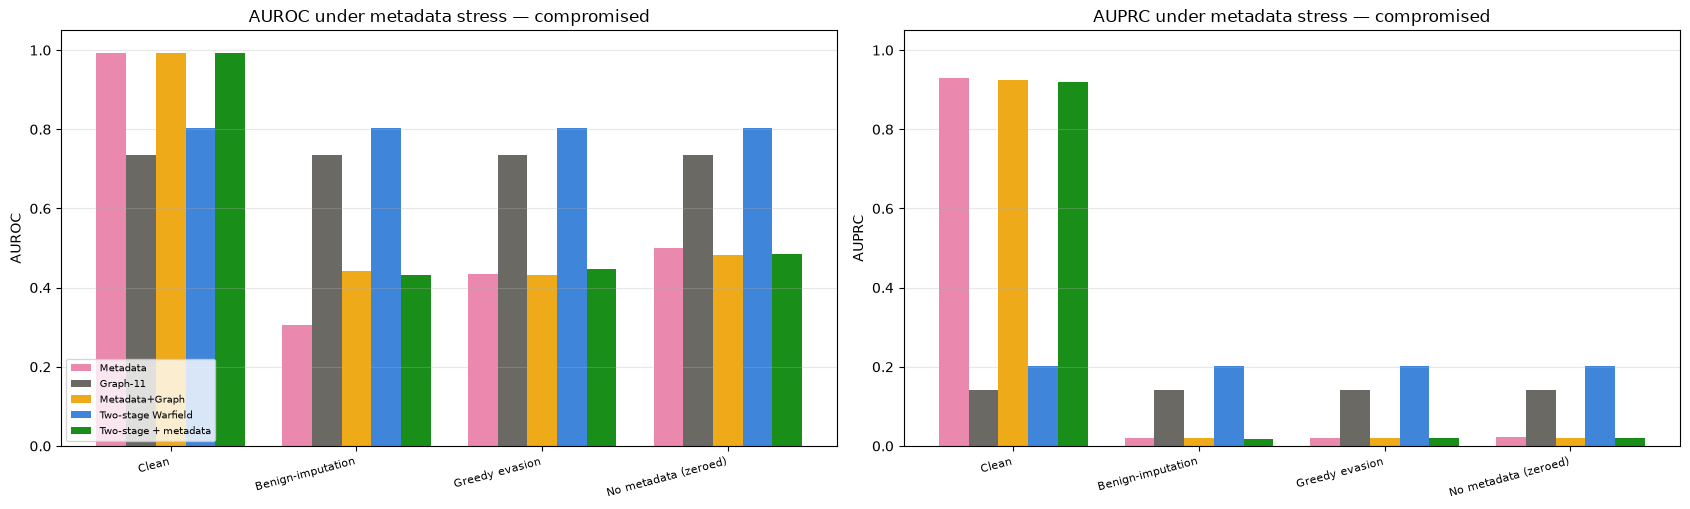

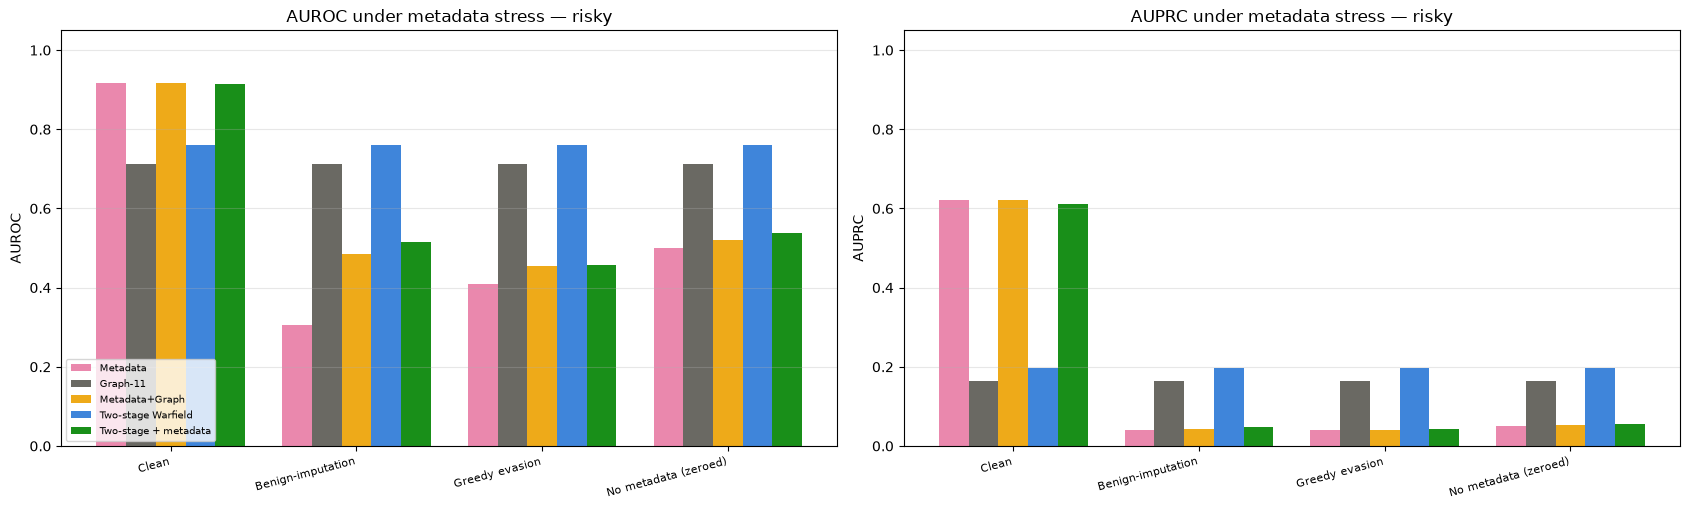

In [7]:
for vname in DETS:
    sub = rob[rob.view == vname]
    dets = [d for d in DET_COLORS if d in set(sub.detector)]
    fig, axes = plt.subplots(1, 2, figsize=(17, 5.2))
    xc = np.arange(len(CONDITIONS)); wd = 0.8 / max(len(dets), 1)
    for ax, metric in zip(axes, ["AUROC", "AUPRC"]):
        for i, d in enumerate(dets):
            vals = [float(sub[(sub.detector == d) & (sub.condition == c)][metric].iloc[0])
                    for c in CONDITIONS]
            ax.bar(xc + (i - (len(dets) - 1) / 2) * wd, vals, wd, label=d,
                   color=DET_COLORS[d], alpha=0.9)
        ax.set_xticks(xc); ax.set_xticklabels(CONDITIONS, rotation=15, ha="right", fontsize=8)
        ax.set_ylim(0, 1.05); ax.set_ylabel(metric)
        ax.set_title(f"{metric} under metadata stress — {vname}")
        ax.grid(axis="y", alpha=0.3)
    axes[0].legend(fontsize=7.5, loc="lower left")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"robustness_{vname}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)

## 7. Metadata-coverage sweep

       view  coverage  Metadata  Graph-11  Metadata+Graph  Two-stage Warfield  Two-stage + metadata
compromised    1.0000    0.9920    0.7359          0.9924              0.8036                0.9919
compromised    0.7500    0.9433    0.7359          0.9442              0.8036                0.9443
compromised    0.5000    0.8474    0.7359          0.8471              0.8036                0.8482
compromised    0.2500    0.7026    0.7359          0.6931              0.8036                0.6991
compromised    0.1000    0.5837    0.7359          0.5646              0.8036                0.5690
compromised    0.0000    0.5000    0.7359          0.4817              0.8036                0.4842
      risky    1.0000    0.9170    0.7134          0.9165              0.7613                0.9149
      risky    0.7500    0.8527    0.7134          0.8545              0.7613                0.8560
      risky    0.5000    0.7691    0.7134          0.7711              0.7613                0.7771


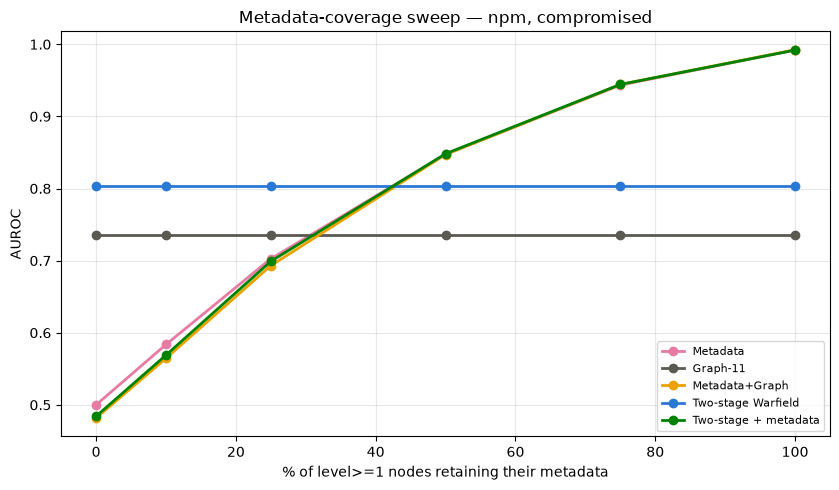

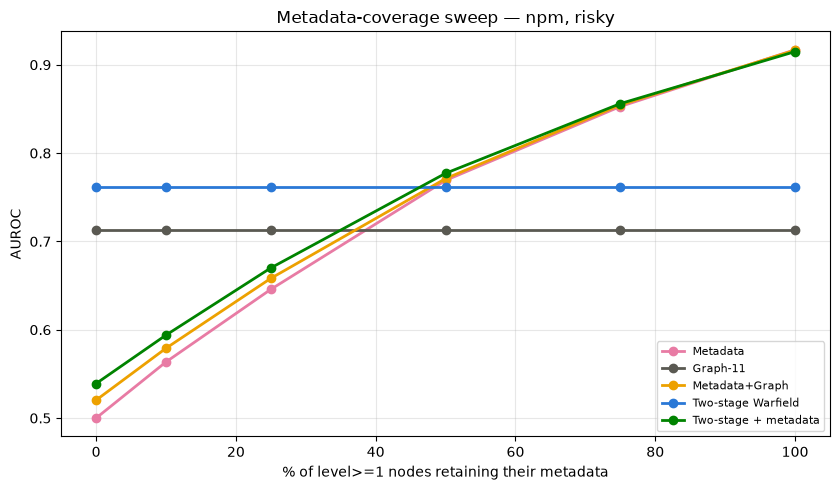

In [8]:
cov_rows = []
for vname, D in DETS.items():
    yd, folds = D["y"], FOLDS_BY_VIEW[vname]
    for p in COVERAGES:
        keep = np.random.default_rng(SEED + int(p * 1000)).random(len(yd)) < p
        row = {"view": vname, "coverage": p}
        for name, Xd in D["DET"].items():
            span = D["SPAN"][name]
            if span is None:
                row[name] = float(roc_auc_score(yd, D["oof"][name]))
                continue
            a0, a1 = span; s = np.zeros(len(yd))
            for k, (tr, te) in enumerate(folds):
                Xte = Xd[te].copy(); Xte[~keep[te], a0:a1] = 0.0
                s[te] = D["models"][name][k].predict_proba(Xte)[:, 1]
            row[name] = float(roc_auc_score(yd, s))
        cov_rows.append(row)
cov = pd.DataFrame(cov_rows)
cov.to_csv(OUT_DIR / "coverage_sweep.csv", index=False)
print(cov.to_string(index=False, float_format="{:.4f}".format))

for vname in DETS:
    sub = cov[cov.view == vname]
    fig, ax = plt.subplots(figsize=(8.5, 5))
    for d in DET_COLORS:
        if d in sub.columns:
            ax.plot(sub["coverage"] * 100, sub[d], marker="o", lw=2,
                    color=DET_COLORS[d], label=d)
    ax.set_xlabel("% of level>=1 nodes retaining their metadata")
    ax.set_ylabel("AUROC"); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="lower right")
    ax.set_title(f"Metadata-coverage sweep — {ECO_TITLE}, {vname}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"coverage_sweep_{vname}.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)

## 8. Summary

In [10]:
summary = {"ecosystem": ECO, "views": ",".join(DETS),
            "n_level0": int(len(l0)), "n_level_ge1": int(len(dn)),
            "runtime_min": (time.time() - t_nb) / 60}
for vname in DETS:
    a, var, note = ALPHA_FOR[vname]
    summary[f"{vname}_alpha"] = a
    summary[f"{vname}_variant"] = var
    summary[f"{vname}_alpha_source"] = note
    c = clean_df[clean_df.view == vname].set_index("detector")
    r = rob[(rob.view == vname) & (rob.condition == "Greedy evasion")].set_index("detector")
    for d in c.index:
        summary[f"{vname}_{d}_clean_auroc"] = round(float(c.loc[d, "AUROC"]), 4)
        summary[f"{vname}_{d}_greedy_auroc"] = round(float(r.loc[d, "AUROC"]), 4)
    summary[f"{vname}_best_clean"] = c["AUROC"].idxmax()
    summary[f"{vname}_best_under_attack"] = r["AUROC"].idxmax()
pd.Series(summary).to_frame("value").to_csv(OUT_DIR / "summary.csv")
print(pd.Series(summary).to_string())

ecosystem                                                               npm
views                                                     compromised,risky
n_level0                                                              14822
n_level_ge1                                                           70457
runtime_min                                                       32.457612
compromised_alpha                                                       0.1
compromised_variant                                       Weighted (log dp)
compromised_alpha_source                         inherited from notebook 04
compromised_Metadata_clean_auroc                                      0.992
compromised_Metadata_greedy_auroc                                    0.4352
compromised_Graph-11_clean_auroc                                     0.7359
compromised_Graph-11_greedy_auroc                                    0.7359
compromised_Metadata+Graph_clean_auroc                               0.9924
compromised_